cuda
9593
1199
1200


model.safetensors: reconstructing file:   0%|          |  0.00B /  102MB            

model.safetensors: downloading bytes:           |  0.00B            

100%|██████████| 600/600 [01:57<00:00,  5.12it/s]



Epoch 1/5

Train Accuracy : 0.6271

Validation Accuracy : 0.9266



...


Epoch 3/5

Train Accuracy : 0.9750

Validation Accuracy : 0.9983



100%|██████████| 600/600 [01:55<00:00,  5.20it/s]



Epoch 4/5

Train Accuracy : 0.9843

Validation Accuracy : 0.9983



100%|██████████| 600/600 [01:54<00:00,  5.23it/s]



Epoch 5/5

Train Accuracy : 0.9862

Validation Accuracy : 0.9983

TEST ACCURACY: 0.9925
                          precision    recall  f1-score   support

            Angiosarcoma       1.00      0.99      0.99       238
      Cholangiocarcinoma       0.99      1.00      0.99       252
                 Healthy       1.00      1.00      1.00       240
              Hemangioma       1.00      0.98      0.99       237
Hepatocellular_Carcinoma       0.98      1.00      0.99       233

                accuracy                           0.99      1200
               macro avg       0.99      0.99      0.99      1200
            weighted avg       0.99      0.99      0.99      1200



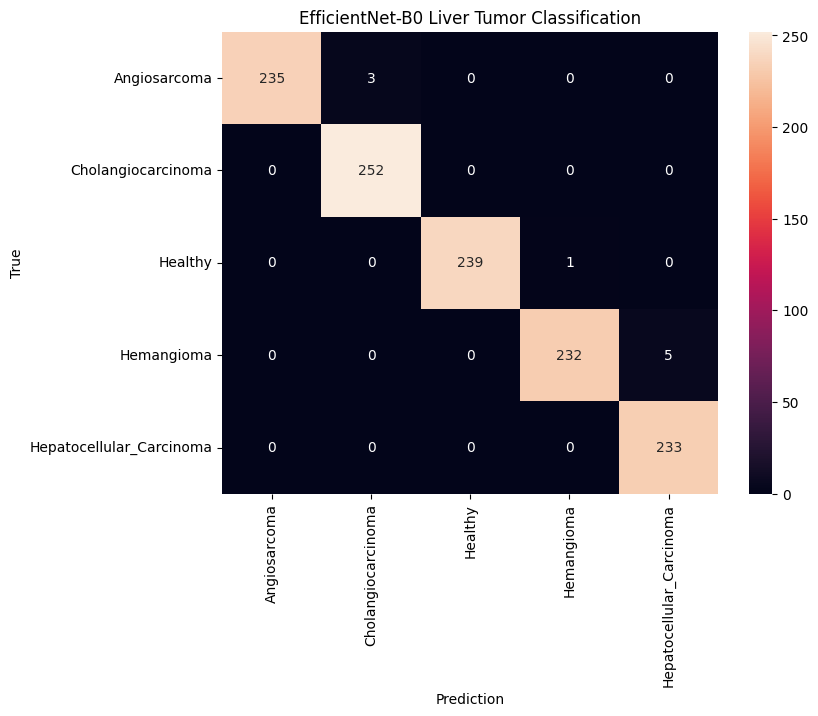

In [10]:
# =====================================
# 1. PARAMETERS
# =====================================

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import numpy as np
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import timm
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm



device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)


IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 5
LR = 3e-5



# =====================================
# 2. TRANSFORMS
# =====================================

train_transform = transforms.Compose([

    transforms.Resize((IMG_SIZE,IMG_SIZE)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])



val_transform = transforms.Compose([

    transforms.Resize((IMG_SIZE,IMG_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])



# =====================================
# 3. SPLIT DATASET
# =====================================


targets = np.array(dataset.targets)

indices = np.arange(len(dataset))


train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=targets
)


val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    random_state=42,
    stratify=targets[temp_idx]
)


print(len(train_idx))
print(len(val_idx))
print(len(test_idx))



# =====================================
# 4. CUSTOM DATASET
# =====================================


class LiverDataset(Dataset):

    def __init__(self, dataset, indices, transform):

        self.dataset = dataset
        self.indices = indices
        self.transform = transform


    def __len__(self):

        return len(self.indices)


    def __getitem__(self,idx):

        real_idx = self.indices[idx]

        img_path,label = self.dataset.samples[real_idx]

        image = Image.open(
            img_path
        ).convert("RGB")


        image = self.transform(image)


        return image,label




train_dataset = LiverDataset(
    dataset,
    train_idx,
    train_transform
)


val_dataset = LiverDataset(
    dataset,
    val_idx,
    val_transform
)


test_dataset = LiverDataset(
    dataset,
    test_idx,
    val_transform
)




# =====================================
# 5. DATALOADER
# =====================================


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)


val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)



# =====================================
# 6. MODEL
# =====================================


model = timm.create_model(
    "resnet50",
    pretrained=True,
    num_classes=len(dataset.classes)
)

model = model.to(device)


# =====================================
# 7. LOSS + OPTIMIZER
# =====================================


criterion = nn.CrossEntropyLoss(
    label_smoothing=0.1
)


optimizer = optim.AdamW(

    model.parameters(),

    lr=LR,

    weight_decay=1e-4
)



scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)



# =====================================
# 8. TRAINING
# =====================================


best_acc = 0


for epoch in range(EPOCHS):


    model.train()


    total=0
    correct=0
    loss_total=0


    for images,labels in tqdm(train_loader):


        images=images.to(device)
        labels=labels.to(device)


        optimizer.zero_grad()


        outputs=model(images)


        loss=criterion(
            outputs,
            labels
        )


        loss.backward()

        optimizer.step()



        loss_total += loss.item()


        pred=torch.argmax(
            outputs,
            dim=1
        )


        correct += (
            pred==labels
        ).sum().item()


        total += labels.size(0)



    train_acc = correct/total



    # validation

    model.eval()

    correct=0
    total=0


    with torch.no_grad():

        for images,labels in val_loader:


            images=images.to(device)
            labels=labels.to(device)


            outputs=model(images)


            pred=torch.argmax(
                outputs,
                dim=1
            )


            correct += (
                pred==labels
            ).sum().item()


            total += labels.size(0)



    val_acc = correct/total



    scheduler.step()



    print(
        f"""
Epoch {epoch+1}/{EPOCHS}

Train Accuracy : {train_acc:.4f}

Validation Accuracy : {val_acc:.4f}
"""
    )



    if val_acc > best_acc:

        best_acc = val_acc

        torch.save(
            model.state_dict(),
            "efficientnet_b0_best.pth"
        )


# =====================================
# 9. TEST
# =====================================


model.load_state_dict(
    torch.load(
        "efficientnet_b0_best.pth"
    )
)


model.eval()


y_true=[]
y_pred=[]


with torch.no_grad():

    for images,labels in test_loader:


        images=images.to(device)


        outputs=model(images)


        pred=torch.argmax(
            outputs,
            dim=1
        )


        y_pred.extend(
            pred.cpu().numpy()
        )


        y_true.extend(
            labels.numpy()
        )



print(
"TEST ACCURACY:",
accuracy_score(
    y_true,
    y_pred
)
)



print(
classification_report(
    y_true,
    y_pred,
    target_names=dataset.classes
)
)



# Confusion matrix

cm=confusion_matrix(
    y_true,
    y_pred
)


plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=dataset.classes,
    yticklabels=dataset.classes
)

plt.xlabel("Prediction")
plt.ylabel("True")
plt.title("EfficientNet-B0 Liver Tumor Classification")

plt.show()

In [3]:
DATA_DIR = "/kaggle/input/liver-cancer-multiclass-dataset/Liver_Dataset/Liver_Dataset"